In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

## Data Extraction

In [2]:
df = pd.read_csv(r"G:\aarchi_eda\Datasets\StudentsPerformance.csv")
df.head(5)

,Id,gender,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score
0,1,female,group B,bachelor's degree,none,72,72,74
1,2,female,group C,some college,completed,69,90,88
2,3,female,group B,master's degree,none,90,95,93
3,4,male,group A,associate's degree,none,47,57,44
4,5,male,group C,some college,none,76,78,75


In [3]:
df.tail(5)

,Id,gender,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score
995,996,female,group E,master's degree,completed,88,99,95
996,997,male,group C,high school,none,62,55,55
997,998,female,group C,high school,completed,59,71,65
998,999,female,group D,some college,completed,68,78,77
999,1000,female,group D,some college,none,77,86,86


## Data Cleaning

In [4]:
df.dtypes 

Id                              int64
gender                         object
race/ethnicity                 object
parental level of education    object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [5]:
#identifying null values
print(df.isnull().sum()) 

Id                             0
gender                         0
race/ethnicity                 0
parental level of education    0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [6]:
df.shape

(1000, 8)

In [7]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df.shape)

Number of duplicate rows:  (0, 8)


## Data Visualization

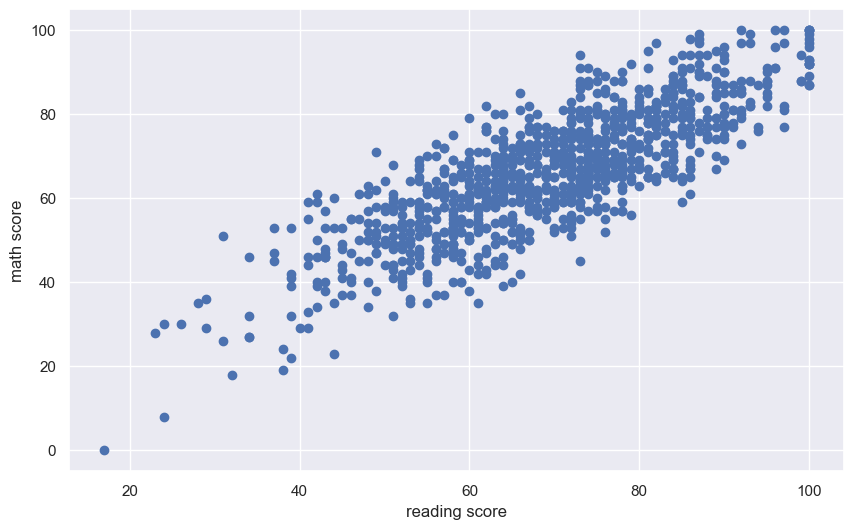

In [8]:
#scatter plot
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['reading score'], df['math score'])
ax.set_xlabel('reading score')
ax.set_ylabel('math score')
plt.show()

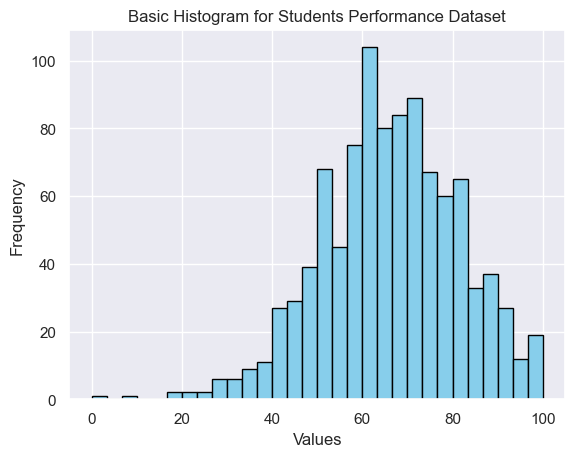

In [9]:
#histogram
plt.hist(x=df['math score'], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram for Students Performance Dataset')

plt.show()

In [10]:
df = df.rename(columns={"test preparation course": "preparation","math score": "math", "reading score":"read", "writing score":"write"})
df.head(5)

,Id,gender,race/ethnicity,parental level of education,preparation,math,read,write
0,1,female,group B,bachelor's degree,none,72,72,74
1,2,female,group C,some college,completed,69,90,88
2,3,female,group B,master's degree,none,90,95,93
3,4,male,group A,associate's degree,none,47,57,44
4,5,male,group C,some college,none,76,78,75


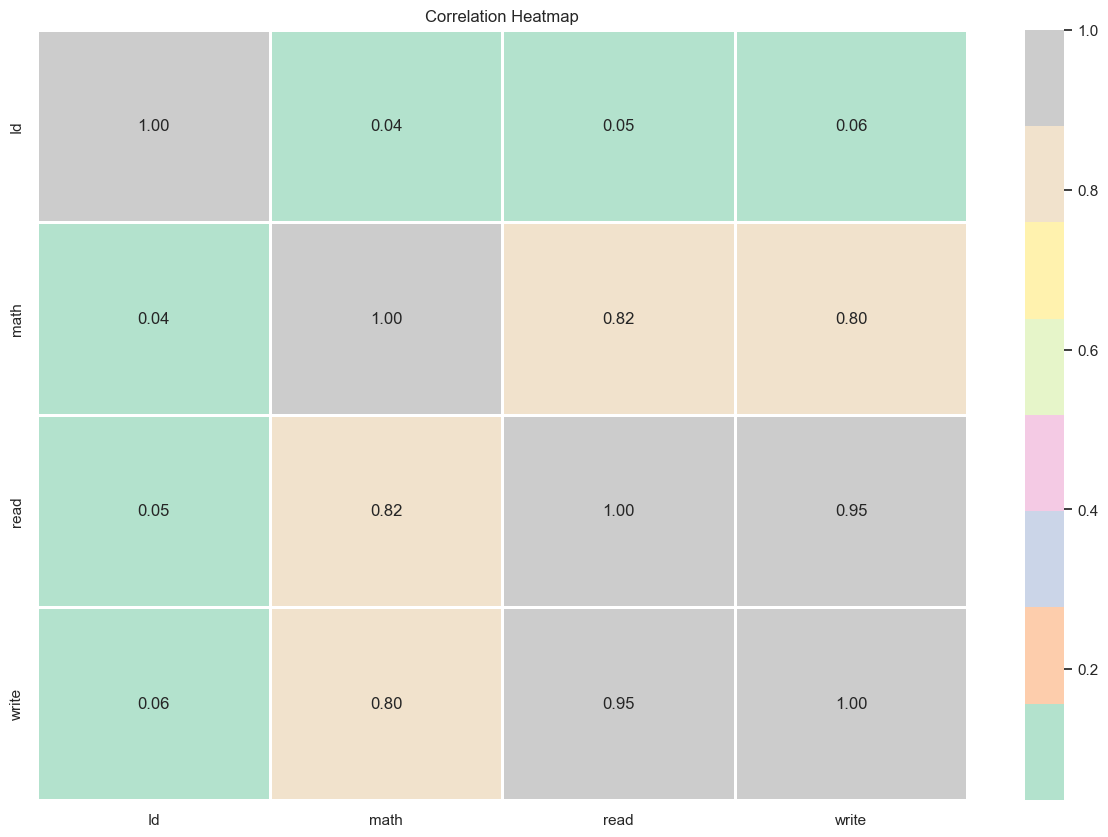

In [12]:
selected_columns = ['Id', 'gender', 'preparation', 'math', 'read', 'write']
df_selected = df[selected_columns]


plt.figure(figsize=(15, 10))

# Seaborn for heatmap
corr_matrix = df_selected.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()